In [1]:
import functions.cnn_helpers as help_funcs
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score, ConfusionMatrixDisplay

import torch

### Define model, criterion and optimizers

In [ ]:
# Hyperparameters - extracted from best model in Rajpurkar et al. 2021
LR = 0.00001
WEIGHT_DECAY = 0.000005
BATCH_SIZE = 32
EPOCHS = 500
IMAGE_SIZE = 52
DEVICE="mps"

# Define transform - adapted to image size in Rajpurkar et al. 2021 
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
])

### Train and evaluate on 5 different splits

Reading training and validation sets in fold 0...
Training model in fold 0...
Reading training and validation sets in fold 1...
Training model in fold 1...
Reading training and validation sets in fold 2...
Training model in fold 2...


KeyboardInterrupt: 

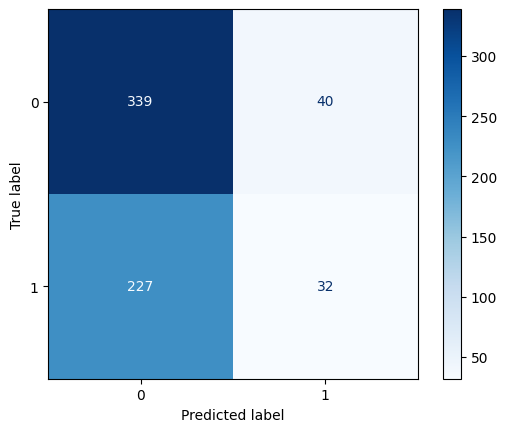

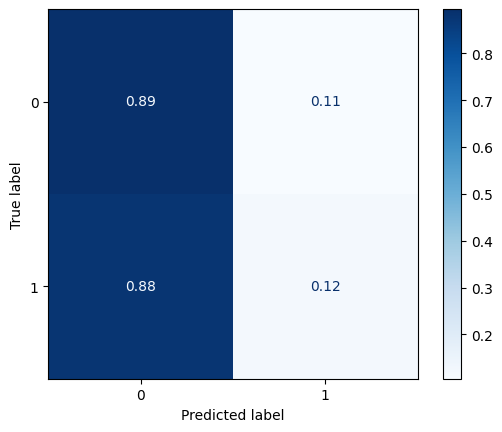

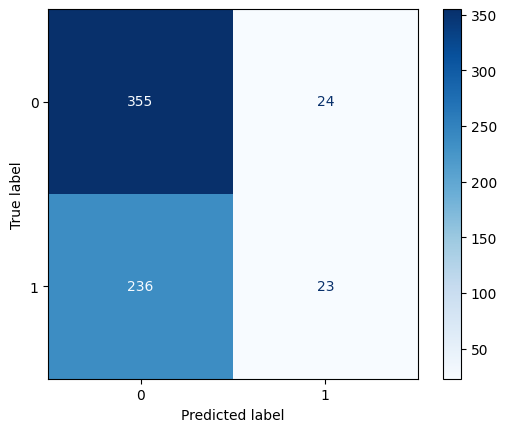

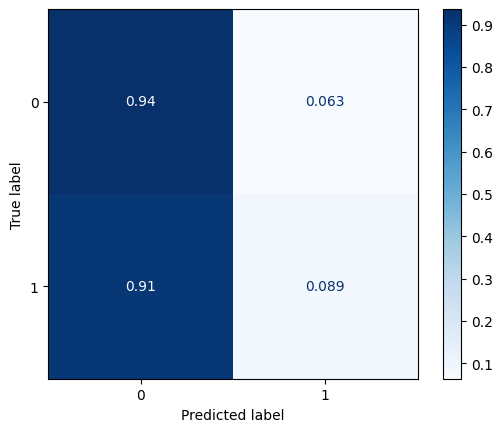

In [3]:
for split_i in range(0, 5):
    print(f'Reading training and validation sets in fold {split_i}...')
    
    # Model
    model = help_funcs.CNN_1(out_1 = 32, kernel_cnn_1 = 7, out_2 = 32, kernel_cnn_2 = 7, h = IMAGE_SIZE, w = IMAGE_SIZE)
    model = model.to(DEVICE)

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr = LR, weight_decay = WEIGHT_DECAY)

    # Criterion - CHECK IF I NEED TO DEFINE WEIGHTS!
    criterion = nn.BCELoss()

    # Create dataset objects
    train_dataset = help_funcs.trace(f'../data/CNN_splits_zscore/fold_{split_i}/train', transform=transform)
    validation_dataset = help_funcs.trace(f'../data/CNN_splits_zscore/fold_{split_i}/validation', transform=transform)
    test_dataset = help_funcs.trace(f'../data/CNN_splits_zscore/fold_{split_i}/test', transform=transform)

    # Create data loaders
    train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
    validation_loader = DataLoader(dataset=validation_dataset, batch_size=32)
    test_loader = DataLoader(dataset=test_dataset, batch_size=32)
    
    # Train model
    print(f'Training model in fold {split_i}...')
    
    train_loss, train_acc, val_loss, val_acc = help_funcs.train_model(n_epochs = EPOCHS, train_loader = train_loader,
                                                                  validation_loader = validation_loader, optimizer = optimizer,
                                                                  model = model, criterion = criterion, device = DEVICE)
    
    # Save loss curves
    fig, ax = plt.subplots(1, 1)
    ax.plot(train_loss, label='training loss')
    ax.plot(val_loss, label='validation_loss')

    ax.set_xlim(0, len(train_loss))
    ax.set_ylim(0, np.max([np.max(val_loss), np.max(train_loss)]))

    ax.legend()
    
    fig.savefig(f'../results/CNN/fold_{split_i}_train_val_loss.png')
    plt.close()
    
    # Evaluate test set
    all_preds, all_pred_scores, all_labels = help_funcs.run_predictions(model, test_loader, DEVICE)
    
    # Calculate accuracy
    accuracy = accuracy_score(all_labels, all_preds)

    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, None]

    # Calculate ROC AUC
    fpr, tpr, thresholds = roc_curve(all_labels, all_pred_scores)
    auc = roc_auc_score(all_labels, all_pred_scores)
    
    # Save evaluation results
    with open(f'../results/CNN/fold_{split_i}_test_results.txt', 'w') as f:
        f.write("EVALUATION RESULTS\n\n")
        f.write(f"Test Accuracy: {accuracy:.4f}\n\n")
        f.write(f"Classification report:\n\n")
        f.write(classification_report(all_labels, all_preds, target_names=['0-inactive', '1-active'], digits=3))
        f.write("\n\nConfusion matrix:\n\n")
        f.write(f"{cm}\n\n")
        f.write("\n\nNormalized confusion matrix:\n\n")
        f.write(f"{cm_norm}\n\n")
        
    f.close()

    # Save ROC
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    ax.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    ax.plot([0, 1], [0, 1], linestyle='--')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")

    fig.savefig(f'../results/CNN/fold_{split_i}_ROC.png')
    plt.close()
    
    # Save confusion matrices
    # Confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    disp.figure_.savefig(f'../results/CNN/fold_{split_i}_confusion_matrix.pdf', format='pdf')
    
    # Normalized confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
    disp.plot(cmap='Blues')
    disp.figure_.savefig(f'../results/CNN/fold_{split_i}_confusion_matrix_normalized.pdf', format='pdf')
    